# Soreal — Knowledge Graph RAG Agent

**Story analysis and investigation** powered by SurrealDB + LangGraph + Ollama + LangSmith.

This notebook implements an agentic pipeline that:

1. **Ingests** unstructured text and chunks it
2. **Extracts** entities and relationships via a local LLM (Ollama)
3. **Verifies** triplets with a human-in-the-loop step
4. **Loads** verified knowledge into a SurrealDB graph (nodes + edges + vectors)
5. **Answers questions** via graph-traversal RAG — and **evolves** the graph during Q&A

### Prerequisites

| Dependency        | How to get it                                                                            |
| ----------------- | ---------------------------------------------------------------------------------------- |
| Python 3.10+      | Already installed                                                                        |
| `uv`              | `brew install uv`                                                                        |
| SurrealDB         | `brew install surrealdb/tap/surreal` then `surreal start --user root --pass root memory` |
| Ollama            | `brew install ollama` then `ollama pull llama3.1:8b`                                     |
| LangSmith API key | Free at https://smith.langchain.com — set in the config cell below                       |

Run the install cell once, restart the kernel, then continue.


In [28]:
# ── Phase 0, Cell 1: Install dependencies ────────────────────────────────────
import shutil, subprocess, sys

packages = [
    "langchain-surrealdb",
    "langchain-ollama",
    "langchain-huggingface",
    "langchain-text-splitters",
    "langgraph",
    "langsmith",
    "surrealdb",
    "sentence-transformers",
    "langchain-core",
    "langchain-community",
    "pandas",
    "python-dotenv",
]

if not shutil.which("uv"):
    raise RuntimeError("uv is not installed. Run: brew install uv")

cmd = ["uv", "pip", "install", "--python", sys.executable, "--upgrade", *packages]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)
print("\n✅  Install complete. Restart the kernel before running the next cell.")

Running: uv pip install --python /Users/eldarutiushev/Projects/Soreal/.venv/bin/python --upgrade langchain-surrealdb langchain-ollama langchain-huggingface langchain-text-splitters langgraph langsmith surrealdb sentence-transformers langchain-core langchain-community pandas python-dotenv

✅  Install complete. Restart the kernel before running the next cell.


Resolved 81 packages in 436ms
Audited 81 packages in 1ms


## Phase 0 — Configuration & Readiness


In [57]:
# ── Phase 0, Cell 2: LangSmith + environment configuration ───────────────────
import os

from dotenv import load_dotenv

load_dotenv()

# LangSmith observability — set your API key here or via env var
os.environ.setdefault("LANGCHAIN_TRACING_V2", "true")
os.environ.setdefault("LANGCHAIN_PROJECT", "soreal-kg-agent")
# Uncomment and paste your key, or export LANGCHAIN_API_KEY before launching:
# os.environ["LANGCHAIN_API_KEY"] = "ls__..."

# SurrealDB
SURREAL_URL = os.getenv("SURREAL_URL", "ws://localhost:8000/rpc")
SURREAL_USERNAME = os.getenv("SURREAL_USERNAME", "root")
SURREAL_PASSWORD = os.getenv("SURREAL_PASSWORD", "root")
SURREAL_NAMESPACE = os.getenv("SURREAL_NAMESPACE", "soreal")
SURREAL_DATABASE = os.getenv("SURREAL_DATABASE", "kg")

# Ollama
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "llama3.1:8b")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

# Embeddings
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
EMBEDDING_DIM = 384

print("Configuration loaded.")
print(f"  SurrealDB:  {SURREAL_URL}")
print(f"  Ollama:     {OLLAMA_BASE_URL} / {OLLAMA_MODEL}")
print(f"  LangSmith:  project={os.environ.get('LANGCHAIN_PROJECT')}")

Configuration loaded.
  SurrealDB:  ws://localhost:8000/rpc
  Ollama:     http://localhost:11434 / llama3.1:8b
  LangSmith:  project=soreal-kg-agent


In [58]:
# ── Phase 0, Cell 3: Readiness checks & connections ──────────────────────────
import socket, time, json
from urllib.parse import urlparse
import urllib.request

# --- SurrealDB check ---
def wait_for_surreal(url: str, timeout: float = 15.0) -> None:
    parsed = urlparse(url)
    host = parsed.hostname or "localhost"
    port = parsed.port or 8000
    deadline = time.time() + timeout
    last_err = None
    while time.time() < deadline:
        try:
            with socket.create_connection((host, port), timeout=2):
                return
        except OSError as e:
            last_err = e
            time.sleep(0.5)
    raise ConnectionError(
        f"SurrealDB not reachable at {url}. Start it in a separate terminal."
    ) from last_err

wait_for_surreal(SURREAL_URL)
print(f"✅  SurrealDB reachable at {SURREAL_URL}")

# --- Ollama check ---
def check_ollama(base_url: str, model: str) -> None:
    try:
        req = urllib.request.Request(f"{base_url}/api/tags")
        with urllib.request.urlopen(req, timeout=5) as resp:
            data = json.loads(resp.read())
            names = [m.get("name", "") for m in data.get("models", [])]
            if not any(model in n for n in names):
                print(f"⚠️  Model '{model}' not found. Available: {names}")
                print(f"   Run: ollama pull {model}")
            else:
                print(f"✅  Ollama ready with model {model}")
    except Exception as e:
        raise ConnectionError(
            f"Ollama not reachable at {base_url}. Start it with: ollama serve"
        ) from e

check_ollama(OLLAMA_BASE_URL, OLLAMA_MODEL)

# --- Connect to SurrealDB ---
from surrealdb import Surreal

conn = Surreal(SURREAL_URL)
conn.signin({"username": SURREAL_USERNAME, "password": SURREAL_PASSWORD})
conn.use(SURREAL_NAMESPACE, SURREAL_DATABASE)
print(f"✅  Connected: ns={SURREAL_NAMESPACE} db={SURREAL_DATABASE}")

# --- Embeddings ---
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)
print(f"✅  Embedding model loaded: {EMBEDDING_MODEL} (dim={EMBEDDING_DIM})")

# --- LLM ---
from langchain_ollama import ChatOllama

llm = ChatOllama(model=OLLAMA_MODEL, base_url=OLLAMA_BASE_URL, temperature=0)
print(f"✅  LLM ready: {OLLAMA_MODEL}")

✅  SurrealDB reachable at ws://localhost:8000/rpc
✅  Ollama ready with model llama3.1:8b
✅  Connected: ns=soreal db=kg
✅  Embedding model loaded: BAAI/bge-small-en-v1.5 (dim=384)
✅  LLM ready: llama3.1:8b


## Phase 1 — SurrealDB Schema & Agent Tools

Define the knowledge graph schema and the tools the agent will use.


In [59]:
# ── Phase 1, Cell 4: Define SurrealDB schema ─────────────────────────────────

SCHEMA_STATEMENTS = [
    # Node tables
    "DEFINE TABLE IF NOT EXISTS character SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label  ON character TYPE string",
    "DEFINE FIELD IF NOT EXISTS type   ON character TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector ON character TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS object SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label      ON object TYPE string",
    "DEFINE FIELD IF NOT EXISTS properties ON object TYPE option<array<string>>",
    "DEFINE FIELD IF NOT EXISTS vector     ON object TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS action SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON action TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON action TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS thought SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS content ON thought TYPE string",

    "DEFINE TABLE IF NOT EXISTS chunk SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS content     ON chunk TYPE string",
    "DEFINE FIELD IF NOT EXISTS source      ON chunk TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS chunk_index ON chunk TYPE int",
    "DEFINE FIELD IF NOT EXISTS vector      ON chunk TYPE option<array<float>>",

    # Edge tables
    "DEFINE TABLE IF NOT EXISTS relates_to   TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS type         ON relates_to TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON relates_to TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS performed    TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON performed TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS has_thought  TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON has_thought TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS mentioned_in TYPE RELATION SCHEMAFULL",

    # Vector indexes (HNSW)
    "DEFINE INDEX IF NOT EXISTS idx_character_vec ON character FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_object_vec    ON object    FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_chunk_vec     ON chunk     FIELDS vector HNSW DIMENSION 384 DIST COSINE",
]

for stmt in SCHEMA_STATEMENTS:
    conn.query(stmt + ";")

print("✅  Schema defined. Verifying...")
info = conn.query("INFO FOR DB;")
print(json.dumps(info, indent=2)[:2000])

✅  Schema defined. Verifying...
{
  "accesses": {},
  "analyzers": {},
  "apis": {},
  "buckets": {},
  "configs": {},
  "functions": {},
  "models": {},
  "modules": {},
  "params": {},
  "sequences": {},
  "tables": {
    "action": "DEFINE TABLE action TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "character": "DEFINE TABLE character TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "chunk": "DEFINE TABLE chunk TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "has_thought": "DEFINE TABLE has_thought TYPE RELATION SCHEMAFULL PERMISSIONS NONE",
    "mentioned_in": "DEFINE TABLE mentioned_in TYPE RELATION SCHEMAFULL PERMISSIONS NONE",
    "object": "DEFINE TABLE object TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "performed": "DEFINE TABLE performed TYPE RELATION SCHEMAFULL PERMISSIONS NONE",
    "relates_to": "DEFINE TABLE relates_to TYPE RELATION SCHEMAFULL PERMISSIONS NONE",
    "thought": "DEFINE TABLE thought TYPE NORMAL SCHEMAFULL PERMISSIONS NONE"
  },
  "users": {}
}


In [75]:
# ── Phase 1, Cell 5: Define agent tools ───────────────────────────────────────
import hashlib
import json
import re
from collections import Counter
from langchain_core.tools import tool
from langchain_text_splitters import RecursiveCharacterTextSplitter


# ---------------------------------------------------------------------------
# Shared helpers
# ---------------------------------------------------------------------------
ENTITY_EXTRACTION_PROMPT = """You are a Named-Entity Recognition system.

Given the following text, extract ALL entities as a JSON array.
Each element must be an object with exactly these keys:
  "label"       – the entity name as it appears in the text
  "entity_type" – one of: character, object, action, thought

Return ONLY the JSON array — no markdown fences, no commentary.

Text:
{text}
"""

TRIPLET_FORMATION_PROMPT = """You are a Relation Extraction system.

Given the text and the approved entity list below, extract ALL relationships as a JSON array.
Each element must be an object with exactly these keys:
  "subject"         – entity label (must be from the list)
  "subject_type"    – entity type of the subject
  "predicate"       – one of: relates_to, performed, has_thought
  "predicate_label" – a short description of the relationship
  "object"          – entity label (must be from the list)
  "object_type"     – entity type of the object

Rules:
- "performed" edges MUST go from a character to an action.
- "has_thought" edges MUST go from a character to a thought.
- "relates_to" edges connect character↔character or character↔object or object↔object.

Return ONLY the JSON array — no markdown fences, no commentary.

Text:
{text}

Approved entities:
{entities_json}
"""


ENTITY_TYPE_PRIORITY = {
    "character": 4,
    "thought": 3,
    "object": 2,
    "action": 1,
}


def _record_params(record_id: str, prefix: str) -> dict[str, str]:
    table, key = str(record_id).split(":", 1)
    return {f"{prefix}_table": table, f"{prefix}_key": key}


def _rows(result):
    if not result:
        return []
    if isinstance(result[0], list):
        return result[0]
    return result


def _clean_label(value: str) -> str:
    value = str(value or "").strip().strip('"').strip("'")
    return re.sub(r"\s+", " ", value)


def _normalized_key(entity_type: str, label: str) -> tuple[str, str]:
    entity_type = _clean_label(entity_type).lower()
    label = re.sub(r"[^a-z0-9]+", " ", _clean_label(label).lower()).strip()
    return entity_type, label


def _normalized_label(label: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", _clean_label(label).lower()).strip()


def _choose_canonical_type(type_counts: Counter) -> str:
    if not type_counts:
        return "object"
    ranked = sorted(
        type_counts.items(),
        key=lambda item: (-item[1], -ENTITY_TYPE_PRIORITY.get(item[0], 0), item[0]),
    )
    return ranked[0][0]


def _safe_json_array(raw: str) -> list:
    text = str(raw or "").strip()
    if not text:
        return []
    try:
        data = json.loads(text)
        return data if isinstance(data, list) else []
    except json.JSONDecodeError:
        pass

    try:
        start = text.index("[")
        end = text.rindex("]") + 1
        data = json.loads(text[start:end])
        return data if isinstance(data, list) else []
    except (ValueError, json.JSONDecodeError):
        return []


def _chunk_ids_from_text(chunk_ids: str) -> list[str]:
    ids = re.findall(r"chunk:[A-Za-z0-9_-]+", str(chunk_ids or ""))
    if ids:
        return ids
    return [cid.strip() for cid in str(chunk_ids or "").split(",") if cid.strip()]


def _load_chunk(chunk_id: str) -> dict:
    rows = _rows(
        conn.query(
            "SELECT id, content, source, chunk_index FROM type::record($chunk_table, $chunk_key);",
            _record_params(chunk_id, "chunk"),
        )
    )
    return rows[0] if rows else {}


def _entity_type_counts(entities: list[dict]) -> dict[str, int]:
    counts = Counter()
    for entity in entities:
        entity_type = _clean_label(entity.get("entity_type", "")).lower()
        if entity_type:
            counts[entity_type] += 1
    return dict(sorted(counts.items()))


# ---------------------------------------------------------------------------
# Tool 1: ingest_text — chunk + embed + store
# ---------------------------------------------------------------------------
@tool
def ingest_text(text: str, source: str = "unknown") -> str:
    """Chunk text, embed each chunk, and store in SurrealDB. Returns comma-separated chunk IDs."""
    splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=60, separators=["\n\n", "\n", ". ", " "])
    chunks = splitter.split_text(text)
    ids = []
    for index, chunk_text in enumerate(chunks):
        chunk_id = f"chunk:{hashlib.md5(f'{source}:{index}'.encode()).hexdigest()}"
        vector = embeddings.embed_query(chunk_text)
        conn.query(
            "UPSERT type::record($chunk_table, $chunk_key) SET content=$content, source=$source, chunk_index=$idx, vector=$vec;",
            {
                **_record_params(chunk_id, "chunk"),
                "content": chunk_text,
                "source": source,
                "idx": index,
                "vec": vector,
            },
        )
        ids.append(chunk_id)
    return ",".join(ids)


# ---------------------------------------------------------------------------
# Tool 2: extract_entity_candidates — raw entity extraction only
# ---------------------------------------------------------------------------
@tool
def extract_entity_candidates(chunk_ids: str) -> str:
    """Extract raw entity candidates from stored chunks without forming triplets."""
    all_entities = []
    for chunk_id in _chunk_ids_from_text(chunk_ids):
        chunk = _load_chunk(chunk_id)
        content = chunk.get("content", "")
        if not content:
            continue
        prompt = ENTITY_EXTRACTION_PROMPT.format(text=content)
        response = llm.invoke(prompt)
        candidates = _safe_json_array(response.content)
        for candidate in candidates:
            if not isinstance(candidate, dict):
                continue
            label = _clean_label(candidate.get("label", ""))
            entity_type = _clean_label(candidate.get("entity_type", "")).lower()
            if not label or entity_type not in {"character", "object", "action", "thought"}:
                continue
            all_entities.append(
                {
                    "label": label,
                    "entity_type": entity_type,
                    "source_chunk": chunk_id,
                    "evidence": content[:120],
                }
            )
    return json.dumps(all_entities, indent=2)


# ---------------------------------------------------------------------------
# Tool 3: merge_entity_candidates — global dedup + review list
# ---------------------------------------------------------------------------
@tool
def merge_entity_candidates(raw_entities_json: str) -> str:
    """Merge raw entity candidates into a global deduplicated review list."""
    raw_entities = _safe_json_array(raw_entities_json)
    merged: dict[str, dict] = {}
    for entity in raw_entities:
        if not isinstance(entity, dict):
            continue
        label = _clean_label(entity.get("label", ""))
        entity_type = _clean_label(entity.get("entity_type", "")).lower()
        if not label or entity_type not in {"character", "object", "action", "thought"}:
            continue
        normalized = _normalized_label(label)
        if not normalized:
            continue

        bucket = merged.setdefault(
            normalized,
            {
                "label_counts": Counter(),
                "type_counts": Counter(),
                "aliases": set(),
                "source_chunks": set(),
                "evidence": [],
                "mention_count": 0,
            },
        )
        bucket["label_counts"][label] += 1
        bucket["type_counts"][entity_type] += 1
        bucket["aliases"].add(label)
        if entity.get("source_chunk"):
            bucket["source_chunks"].add(entity["source_chunk"])
        if entity.get("evidence"):
            bucket["evidence"].append(_clean_label(entity["evidence"]))
        bucket["mention_count"] += 1

    merged_entities = []
    for normalized_label, bucket in merged.items():
        canonical_type = _choose_canonical_type(bucket["type_counts"])
        canonical_label = sorted(
            bucket["label_counts"].items(),
            key=lambda item: (-item[1], len(item[0]), item[0].lower()),
        )[0][0]
        merged_entities.append(
            {
                "entity_id": f"{canonical_type}:{hashlib.md5(f'{canonical_type}:{normalized_label}'.encode()).hexdigest()[:12]}",
                "label": canonical_label,
                "entity_type": canonical_type,
                "type_candidates": dict(sorted(bucket["type_counts"].items())),
                "aliases": sorted(bucket["aliases"]),
                "source_chunks": sorted(bucket["source_chunks"]),
                "evidence": bucket["evidence"][:5],
                "mention_count": bucket["mention_count"],
            }
        )

    merged_entities.sort(key=lambda item: (item["entity_type"], item["label"].lower()))
    return json.dumps(merged_entities, indent=2)


# ---------------------------------------------------------------------------
# Tool 4: form_triplets_from_entities — relationships from approved entities
# ---------------------------------------------------------------------------
@tool
def form_triplets_from_entities(chunk_ids: str, approved_entities_json: str) -> str:
    """Create triplets using only the approved global entity list."""
    approved_entities = []
    for entity in _safe_json_array(approved_entities_json):
        if not isinstance(entity, dict):
            continue
        label = _clean_label(entity.get("label", ""))
        entity_type = _clean_label(entity.get("entity_type", "")).lower()
        if not label or entity_type not in {"character", "object", "action", "thought"}:
            continue
        approved_entities.append(
            {
                "label": label,
                "entity_type": entity_type,
                "source_chunks": entity.get("source_chunks", []),
                "aliases": entity.get("aliases", []),
            }
        )

    all_triplets = []
    for chunk_id in _chunk_ids_from_text(chunk_ids):
        chunk = _load_chunk(chunk_id)
        content = chunk.get("content", "")
        if not content:
            continue

        chunk_entities = [
            entity for entity in approved_entities if chunk_id in entity.get("source_chunks", [])
        ]
        if len(chunk_entities) < 2:
            continue

        catalog = {}
        compact_catalog = []
        for entity in chunk_entities:
            canonical = {"label": entity["label"], "entity_type": entity["entity_type"]}
            catalog[_normalized_key(entity["entity_type"], entity["label"])] = canonical
            compact_catalog.append(canonical)

        prompt = TRIPLET_FORMATION_PROMPT.format(
            text=content,
            entities_json=json.dumps(compact_catalog, indent=2),
        )
        response = llm.invoke(prompt)
        candidates = _safe_json_array(response.content)
        for candidate in candidates:
            if not isinstance(candidate, dict):
                continue

            subject = _clean_label(candidate.get("subject", ""))
            subject_type = _clean_label(candidate.get("subject_type", "")).lower()
            predicate = _clean_label(candidate.get("predicate", "")).lower()
            predicate_label = _clean_label(candidate.get("predicate_label", ""))
            obj = _clean_label(candidate.get("object", ""))
            object_type = _clean_label(candidate.get("object_type", "")).lower()

            if predicate not in {"relates_to", "performed", "has_thought"}:
                continue

            subject_match = catalog.get(_normalized_key(subject_type, subject))
            object_match = catalog.get(_normalized_key(object_type, obj))
            if subject_match is None:
                normalized_subject = _normalized_label(subject)
                subject_match = next(
                    (
                        value
                        for (_, norm_label), value in catalog.items()
                        if norm_label == normalized_subject
                    ),
                    None,
                )
            if object_match is None:
                normalized_object = _normalized_label(obj)
                object_match = next(
                    (
                        value
                        for (_, norm_label), value in catalog.items()
                        if norm_label == normalized_object
                    ),
                    None,
                )

            if subject_match is None or object_match is None:
                continue

            subject_entity_type = subject_match["entity_type"]
            object_entity_type = object_match["entity_type"]
            if predicate == "performed" and not (
                subject_entity_type == "character" and object_entity_type == "action"
            ):
                continue
            if predicate == "has_thought" and not (
                subject_entity_type == "character" and object_entity_type == "thought"
            ):
                continue
            if predicate == "relates_to" and not (
                subject_entity_type in {"character", "object"}
                and object_entity_type in {"character", "object"}
            ):
                continue

            all_triplets.append(
                {
                    "subject": subject_match["label"],
                    "subject_type": subject_entity_type,
                    "predicate": predicate,
                    "predicate_label": predicate_label,
                    "object": object_match["label"],
                    "object_type": object_entity_type,
                    "source_chunk": chunk_id,
                }
            )

    return json.dumps(all_triplets, indent=2)


# ---------------------------------------------------------------------------
# Tool 5: summarize_triplets — pipeline counts for review/load
# ---------------------------------------------------------------------------
@tool
def summarize_triplets(triplets_json: str, approved_triplets_json: str = "") -> str:
    """Return raw and approved triplet counts for notebook review steps."""
    raw_triplets = [item for item in _safe_json_array(triplets_json) if isinstance(item, dict) and item.get("predicate")]
    approved_triplets = [
        item for item in _safe_json_array(approved_triplets_json) if isinstance(item, dict) and item.get("predicate")
    ]

    raw_predicates = Counter(item.get("predicate", "") for item in raw_triplets if item.get("predicate"))
    approved_predicates = Counter(item.get("predicate", "") for item in approved_triplets if item.get("predicate"))

    summary = {
        "total_raw_triplets": len(raw_triplets),
        "total_approved_triplets": len(approved_triplets),
        "raw_by_predicate": dict(sorted(raw_predicates.items())),
        "approved_by_predicate": dict(sorted(approved_predicates.items())),
    }
    return json.dumps(summary, indent=2)


# ---------------------------------------------------------------------------
# Tool 6: search_graph — vector entry-point + graph traversal
# ---------------------------------------------------------------------------
@tool
def search_graph(query: str) -> str:
    """Search the knowledge graph to answer questions about the story."""
    vec = embeddings.embed_query(query)

    entry_nodes = []
    for table in ["character", "object"]:
        results = _rows(
            conn.query(
                f"SELECT id, label, vector::similarity::cosine(vector, $vec) AS score FROM {table} "
                f"WHERE vector <|3,40|> $vec ORDER BY score DESC;",
                {"vec": vec},
            )
        )
        entry_nodes.extend(results)

    if not entry_nodes:
        fallback = _rows(
            conn.query(
                "SELECT id, content, source, vector::similarity::cosine(vector, $vec) AS score "
                "FROM chunk WHERE vector <|3,40|> $vec ORDER BY score DESC;",
                {"vec": vec},
            )
        )
        if fallback:
            return json.dumps({"source": "chunk_fallback", "results": fallback}, indent=2, default=str)
        return "No results found in the knowledge graph."

    context_parts = []
    for node in entry_nodes:
        node_id = node.get("id")
        if not node_id:
            continue
        traversal = _rows(
            conn.query(
                "SELECT id, label, "
                "->relates_to->character.label AS related_characters, "
                "->relates_to->object.label AS related_objects, "
                "->performed->action.label AS actions_performed, "
                "->has_thought->thought.content AS thoughts, "
                "<-relates_to<-character.label AS related_from_characters "
                "FROM type::record($node_table, $node_key);",
                _record_params(node_id, "node"),
            )
        )
        context_parts.append({"node": node, "traversal": traversal[0] if traversal else {}})

    return json.dumps({"source": "graph_traversal", "results": context_parts}, indent=2, default=str)


# ---------------------------------------------------------------------------
# Tool 7: mutate_graph — insert/update nodes and edges
# ---------------------------------------------------------------------------
@tool
def mutate_graph(triplets_json: str) -> str:
    """Insert approved triplets into the SurrealDB knowledge graph."""
    triplets = _safe_json_array(triplets_json)
    if not triplets:
        return "No valid triplets to insert."
    created_nodes = set()
    created_edges = 0

    def _node_id(label: str, entity_type: str) -> str:
        digest = hashlib.md5(f"{entity_type}:{label}".lower().strip().encode()).hexdigest()
        return f"{entity_type}:{digest}"

    def _upsert_node(label: str, entity_type: str) -> str:
        node_id = _node_id(label, entity_type)
        if node_id in created_nodes:
            return node_id
        node_params = _record_params(node_id, "node")
        vector = embeddings.embed_query(label) if entity_type in {"character", "object"} else None
        if entity_type in {"character", "object"}:
            conn.query(
                "UPSERT type::record($node_table, $node_key) SET label=$label, vector=$vec;",
                {**node_params, "label": label, "vec": vector},
            )
        elif entity_type == "action":
            conn.query(
                "UPSERT type::record($node_table, $node_key) SET label=$label;",
                {**node_params, "label": label},
            )
        elif entity_type == "thought":
            conn.query(
                "UPSERT type::record($node_table, $node_key) SET content=$label;",
                {**node_params, "label": label},
            )
        created_nodes.add(node_id)
        return node_id

    for triplet in triplets:
        subject_id = _upsert_node(triplet["subject"].strip(), triplet["subject_type"])
        object_id = _upsert_node(triplet["object"].strip(), triplet["object_type"])
        predicate = triplet["predicate"]
        predicate_label = triplet.get("predicate_label", "")
        source_chunk = triplet.get("source_chunk", "")

        if predicate == "relates_to":
            conn.query(
                "LET $from = type::record($from_table, $from_key); "
                "LET $to = type::record($to_table, $to_key); "
                "RELATE $from->relates_to->$to SET type=$type, source_chunk=$src;",
                {
                    **_record_params(subject_id, "from"),
                    **_record_params(object_id, "to"),
                    "type": predicate_label,
                    "src": source_chunk,
                },
            )
        else:
            conn.query(
                f"LET $from = type::record($from_table, $from_key); "
                f"LET $to = type::record($to_table, $to_key); "
                f"RELATE $from->{predicate}->$to SET source_chunk=$src;",
                {
                    **_record_params(subject_id, "from"),
                    **_record_params(object_id, "to"),
                    "src": source_chunk,
                },
            )
        created_edges += 1

    return f"Created {len(created_nodes)} nodes and {created_edges} edges."


# ---------------------------------------------------------------------------
# Tool 8: get_graph_summary — overview of graph contents
# ---------------------------------------------------------------------------
@tool
def get_graph_summary() -> str:
    """Return a summary of the current knowledge graph contents."""
    tables = ["character", "object", "action", "thought", "chunk"]
    edge_tables = ["relates_to", "performed", "has_thought", "mentioned_in"]

    summary_parts = []
    for table in tables:
        rows = _rows(conn.query(f"SELECT count() AS c FROM {table} GROUP ALL;"))
        count = rows[0].get("c", 0) if rows else 0
        summary_parts.append(f"{table}: {count}")

    for table in edge_tables:
        rows = _rows(conn.query(f"SELECT count() AS c FROM {table} GROUP ALL;"))
        count = rows[0].get("c", 0) if rows else 0
        summary_parts.append(f"{table}: {count}")

    chars = _rows(conn.query("SELECT label, type FROM character;"))
    rels = _rows(conn.query("SELECT in.label AS from_entity, type, out.label AS to_entity FROM relates_to;"))

    return json.dumps(
        {"node_edge_counts": summary_parts, "characters": chars, "relationships": rels},
        indent=2,
        default=str,
    )


ALL_TOOLS = [
    ingest_text,
    extract_entity_candidates,
    merge_entity_candidates,
    form_triplets_from_entities,
    summarize_triplets,
    search_graph,
    mutate_graph,
    get_graph_summary,
]

print("✅  Tools defined:", [t.name for t in ALL_TOOLS])

✅  Tools defined: ['ingest_text', 'extract_entity_candidates', 'merge_entity_candidates', 'form_triplets_from_entities', 'summarize_triplets', 'search_graph', 'mutate_graph', 'get_graph_summary']


## Phase 2 — LangGraph Agent

A `StateGraph` with routed entry handling for two modes:

- Deterministic ingestion and staged extraction with entity review and triplet review
- Interactive Q&A backed by SurrealDB graph search and graph mutation tools


In [76]:
# ── Phase 2, Cell 6: Agent state & graph definition ──────────────────────────
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


class AgentState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    chunk_ids: str
    raw_entities_json: str
    merged_entities_json: str
    approved_entities_json: str
    raw_triplets: str
    approved_triplets: str
    triplet_counts_json: str
    phase: str


QUERY_TOOLS = [search_graph, mutate_graph, get_graph_summary]


def _latest_human_message(state: AgentState):
    return next((msg for msg in reversed(state.get("messages", [])) if isinstance(msg, HumanMessage)), None)


def _count_json_items(value: str) -> int:
    return len(_safe_json_array(value))


def entry_node(state: AgentState) -> dict:
    return {}


def route_from_entry(state: AgentState) -> str:
    latest_human = _latest_human_message(state)
    content = latest_human.content if latest_human else ""
    marker = "Ingest and extract entities from this text:"
    if marker in content:
        return "ingest"
    return "query"


def ingest_node(state: AgentState) -> dict:
    latest_human = _latest_human_message(state)
    if latest_human is None:
        return {"messages": [AIMessage(content="No input text found for ingestion.")], "phase": "ingest"}

    content = latest_human.content
    marker = "Ingest and extract entities from this text:"
    text = content.split(marker, 1)[1].strip() if marker in content else content.strip()
    chunk_ids = ingest_text.invoke({"text": text, "source": "user_input"})
    chunk_count = len(_chunk_ids_from_text(chunk_ids))
    return {
        "chunk_ids": chunk_ids,
        "messages": [AIMessage(content=f"Stored {chunk_count} chunks in SurrealDB.")],
        "phase": "ingest_completed",
    }


def extract_entities_node(state: AgentState) -> dict:
    chunk_ids = state.get("chunk_ids", "")
    if not chunk_ids:
        return {
            "raw_entities_json": "[]",
            "merged_entities_json": "[]",
            "messages": [AIMessage(content="No chunk IDs available for entity extraction.")],
            "phase": "entity_review_pending",
        }

    raw_entities_json = extract_entity_candidates.invoke({"chunk_ids": chunk_ids})
    merged_entities_json = merge_entity_candidates.invoke({"raw_entities_json": raw_entities_json})
    raw_count = _count_json_items(raw_entities_json)
    merged_count = _count_json_items(merged_entities_json)
    return {
        "raw_entities_json": raw_entities_json,
        "merged_entities_json": merged_entities_json,
        "messages": [
            AIMessage(
                content=f"Extracted {raw_count} raw entity mentions and merged them into {merged_count} global review entities."
            )
        ],
        "phase": "entity_review_pending",
    }


def review_entities_node(state: AgentState) -> dict:
    merged_entities_json = state.get("merged_entities_json", "[]")
    review_message = (
        "## Global Merged Entities for Review\n\n"
        f"```json\n{merged_entities_json}\n```\n\n"
        "Edit the JSON array if needed, or type **ok** to accept the merged list as-is."
    )
    user_response = interrupt(review_message)
    approved_entities_json = (
        merged_entities_json if str(user_response).strip().lower() == "ok" else str(user_response).strip()
    )
    approved_count = _count_json_items(approved_entities_json)
    return {
        "approved_entities_json": approved_entities_json,
        "messages": [AIMessage(content=f"Approved {approved_count} entities. Forming triplets next.")],
        "phase": "entities_approved",
    }


def form_triplets_node(state: AgentState) -> dict:
    chunk_ids = state.get("chunk_ids", "")
    approved_entities_json = state.get("approved_entities_json", "[]")
    raw_triplets = form_triplets_from_entities.invoke(
        {"chunk_ids": chunk_ids, "approved_entities_json": approved_entities_json}
    )
    triplet_counts_json = summarize_triplets.invoke({"triplets_json": raw_triplets})
    counts = json.loads(triplet_counts_json or "{}")
    return {
        "raw_triplets": raw_triplets,
        "triplet_counts_json": triplet_counts_json,
        "messages": [
            AIMessage(
                content=(
                    "Formed triplets from the approved entities. "
                    f"Total raw triplets: {counts.get('total_raw_triplets', 0)}."
                )
            )
        ],
        "phase": "triplet_review_pending",
    }


def review_triplets_node(state: AgentState) -> dict:
    raw_triplets = state.get("raw_triplets", "[]")
    triplet_counts_json = state.get("triplet_counts_json", "{}")
    review_message = (
        "## Triplets for Review\n\n"
        f"Counts:\n```json\n{triplet_counts_json}\n```\n\n"
        f"Triplets:\n```json\n{raw_triplets}\n```\n\n"
        "Edit the JSON array if needed, or type **ok** to accept the triplets as-is."
    )
    user_response = interrupt(review_message)
    approved_triplets = raw_triplets if str(user_response).strip().lower() == "ok" else str(user_response).strip()
    final_counts_json = summarize_triplets.invoke(
        {"triplets_json": raw_triplets, "approved_triplets_json": approved_triplets}
    )
    final_counts = json.loads(final_counts_json or "{}")
    return {
        "approved_triplets": approved_triplets,
        "triplet_counts_json": final_counts_json,
        "messages": [
            AIMessage(
                content=(
                    "Triplets approved. "
                    f"Total approved triplets: {final_counts.get('total_approved_triplets', 0)}."
                )
            )
        ],
        "phase": "triplets_approved",
    }


def load_node(state: AgentState) -> dict:
    approved_triplets = state.get("approved_triplets", "")
    if not approved_triplets:
        return {"messages": [AIMessage(content="No approved triplets to load.")], "phase": "loaded"}
    result = mutate_graph.invoke({"triplets_json": approved_triplets})
    return {
        "messages": [AIMessage(content=f"Knowledge graph updated. {result}")],
        "phase": "loaded",
    }


def query_node(state: AgentState) -> dict:
    bound = llm.bind_tools(QUERY_TOOLS)
    system = SystemMessage(
        content=(
            "You are a story-analysis assistant backed by a knowledge graph in SurrealDB. "
            "Use search_graph to find information before answering. "
            "If the user provides new facts, use mutate_graph to add them to the graph. "
            "Use get_graph_summary to see what's in the graph. "
            "Always ground your answers in the graph data returned by tools."
        )
    )
    response = bound.invoke([system] + state.get("messages", []))
    return {"messages": [response], "phase": "query"}


query_tools_executor = ToolNode(QUERY_TOOLS)


def should_continue_query(state: AgentState) -> str:
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "query_tools"
    return END


workflow = StateGraph(AgentState)

workflow.add_node("entry", entry_node)
workflow.add_node("ingest", ingest_node)
workflow.add_node("extract_entities", extract_entities_node)
workflow.add_node("review_entities", review_entities_node)
workflow.add_node("form_triplets", form_triplets_node)
workflow.add_node("review_triplets", review_triplets_node)
workflow.add_node("load", load_node)
workflow.add_node("query", query_node)
workflow.add_node("query_tools", query_tools_executor)

workflow.add_edge(START, "entry")
workflow.add_conditional_edges("entry", route_from_entry, {"ingest": "ingest", "query": "query"})
workflow.add_edge("ingest", "extract_entities")
workflow.add_edge("extract_entities", "review_entities")
workflow.add_edge("review_entities", "form_triplets")
workflow.add_edge("form_triplets", "review_triplets")
workflow.add_edge("review_triplets", "load")
workflow.add_edge("load", END)
workflow.add_conditional_edges("query", should_continue_query, {"query_tools": "query_tools", END: END})
workflow.add_edge("query_tools", "query")

checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

print("✅  LangGraph agent compiled")
print(f"   Nodes: {list(graph.nodes.keys())}")

✅  LangGraph agent compiled
   Nodes: ['__start__', 'entry', 'ingest', 'extract_entities', 'review_entities', 'form_triplets', 'review_triplets', 'load', 'query', 'query_tools']


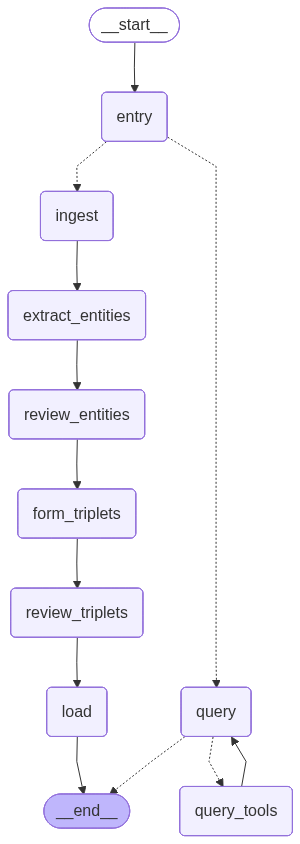

In [34]:
# Visualise the agent graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Phase 3 — Text Ingestion, Entity Extraction, and Stage Inspection

Paste your story text below and run the pipeline cell. The workflow now:

1. Chunks the text and stores chunk vectors in SurrealDB
2. Extracts raw entity candidates from each chunk
3. Merges entities into a single global review list
4. Pauses for entity review before any triplets are formed
5. Forms triplets only from the approved entity list and pauses again for triplet review


In [77]:
# ── Phase 3, Cell 8: Sample story text ────────────────────────────────────────
# Replace with your own text or load from a file.

story_text = """
The Lost Dog
Tom had a dog named Pip. Pip was small, fast, and full of joy. One cold day, Pip ran off into the woods near their home.
Tom called out, "Pip! Pip!" but heard nothing.
His friend Ava came to help. They walked for a long time, checking under logs and behind big rocks.
Then Ava saw two bright eyes in the dark.
"Tom! Over here!"
Pip ran out and jumped into Tom's arms. His tail spun like a fan.
"Bad dog," Tom said softly. But he was smiling.
Ava laughed. "I think Pip wins."
""".strip()

print(f"Story loaded: {len(story_text)} characters")

Story loaded: 487 characters


In [78]:
# ── Phase 3, Cell 9: Run the staged extraction pipeline ───────────────────────
# This streams the agent through ingest → entity extraction → entity review.
# After you approve entities, the same resume cell will continue to triplet review.

import json
import uuid

thread_config = {"configurable": {"thread_id": str(uuid.uuid4())}}

for event in graph.stream(
    {"messages": [HumanMessage(content=f"Ingest and extract entities from this text:\n\n{story_text}")]},
    config=thread_config,
    stream_mode="values",
):
    phase = event.get("phase", "unknown")
    print(f"\n[phase={phase}]")

    if phase == "ingest_completed":
        chunk_count = len(_chunk_ids_from_text(event.get("chunk_ids", "")))
        print(f"Stored chunks: {chunk_count}")

    elif phase == "entity_review_pending":
        raw_entities = _safe_json_array(event.get("raw_entities_json", "[]"))
        merged_entities = _safe_json_array(event.get("merged_entities_json", "[]"))
        print(f"Raw entity candidates: {len(raw_entities)}")
        print(f"Merged review entities: {len(merged_entities)}")

    last_message = event["messages"][-1]
    content = str(getattr(last_message, "content", "")).strip()
    if content:
        print(content[:300])

print("\n─── Pipeline paused at entity review step ───")


[phase=unknown]
Ingest and extract entities from this text:

The Lost Dog
Tom had a dog named Pip. Pip was small, fast, and full of joy. One cold day, Pip ran off into the woods near their home.
Tom called out, "Pip! Pip!" but heard nothing.
His friend Ava came to help. They walked for a long time, checking under l

[phase=ingest_completed]
Stored chunks: 8
Stored 8 chunks in SurrealDB.

[phase=entity_review_pending]
Raw entity candidates: 17
Merged review entities: 6
Extracted 17 raw entity mentions and merged them into 6 global review entities.

[phase=entity_review_pending]
Raw entity candidates: 17
Merged review entities: 6
Extracted 17 raw entity mentions and merged them into 6 global review entities.

─── Pipeline paused at entity review step ───


In [46]:
# ── Phase 3, Cell 10: Inspect current pipeline artifacts ──────────────────────
import json
import pandas as pd

state = graph.get_state(thread_config)
chunk_ids = _chunk_ids_from_text(state.values.get("chunk_ids", ""))
raw_entities = _safe_json_array(state.values.get("raw_entities_json", "[]"))
merged_entities = _safe_json_array(state.values.get("merged_entities_json", "[]"))
approved_entities = _safe_json_array(state.values.get("approved_entities_json", "[]"))
raw_triplets = _safe_json_array(state.values.get("raw_triplets", "[]"))
approved_triplets = _safe_json_array(state.values.get("approved_triplets", "[]"))
triplet_counts = json.loads(state.values.get("triplet_counts_json", "{}") or "{}")

print(f"Current phase: {state.values.get('phase', 'unknown')}")
print(f"Chunk count: {len(chunk_ids)}")
print(f"Raw entity candidates: {len(raw_entities)}")
print(f"Merged entities: {len(merged_entities)}")
print(f"Approved entities: {len(approved_entities)}")
print(f"Raw triplets: {len(raw_triplets)}")
print(f"Approved triplets: {len(approved_triplets)}")

if merged_entities:
    print("\nMerged entity review table:")
    display(
        pd.DataFrame(
            [
                {
                    "label": item.get("label", ""),
                    "entity_type": item.get("entity_type", ""),
                    "mention_count": item.get("mention_count", 0),
                    "aliases": ", ".join(item.get("aliases", [])),
                }
                for item in merged_entities
            ]
        )
    )

if raw_triplets:
    print("\nRaw triplet preview:")
    display(pd.DataFrame(raw_triplets))

if triplet_counts:
    print("\nTriplet counts:")
    print(json.dumps(triplet_counts, indent=2))

Current phase: triplet_review_pending
Chunk count: 4
Raw entity candidates: 20
Merged entities: 15
Approved entities: 15
Raw triplets: 3
Approved triplets: 0

Merged entity review table:


,label,entity_type,mention_count,aliases
0,called,action,1,called
1,jumped,action,1,jumped
2,ran,action,1,ran
3,spun,action,1,spun
4,walked,action,1,walked
5,Ava,character,2,Ava
6,Pip,character,4,Pip
7,Tom,character,2,Tom
8,arms,object,1,arms
9,eyes,object,1,eyes



Raw triplet preview:


,subject,subject_type,predicate,predicate_label,object,object_type,source_chunk
0,Pip,character,relates_to,near,home,object,chunk:8f38c04e1a708d69cc0abd2b58950e7c
1,Ava,character,performed,performed,walked,action,chunk:87111dcf18f586140b38abb129cec94f
2,Pip,character,relates_to,near,arms,object,chunk:ab3ce5779c48dfaeab23d7bd0cc1f11d



Triplet counts:
{
  "total_raw_triplets": 3,
  "total_approved_triplets": 0,
  "raw_by_predicate": {
    "performed": 1,
    "relates_to": 2
  },
  "approved_by_predicate": {}
}


### Optional JSON Artifact Preview

Use this cell when you want the raw JSON artifacts instead of the compact tables.


In [38]:
# Optional: print raw JSON artifacts for the current thread
import json

state = graph.get_state(thread_config)
print("Phase:", state.values.get("phase", "unknown"))
print()
print("RAW ENTITIES")
print(json.dumps(_safe_json_array(state.values.get("raw_entities_json", "[]")), indent=2))
print()
print("MERGED ENTITIES")
print(json.dumps(_safe_json_array(state.values.get("merged_entities_json", "[]")), indent=2))
print()
print("APPROVED ENTITIES")
print(json.dumps(_safe_json_array(state.values.get("approved_entities_json", "[]")), indent=2))
print()
print("RAW TRIPLETS")
print(json.dumps(_safe_json_array(state.values.get("raw_triplets", "[]")), indent=2))
print()
print("TRIPLET COUNTS")
print(json.dumps(json.loads(state.values.get("triplet_counts_json", "{}") or "{}"), indent=2))

Phase: entity_review_pending

RAW ENTITIES
[
  {
    "label": "Pip",
    "entity_type": "object",
    "evidence": "Pip was small, fast, and full of joy.",
    "source_chunk": "chunk:8f38c04e1a708d69cc0abd2b58950e7c",
    "chunk_index": 0
  },
  {
    "label": "Tom",
    "entity_type": "character",
    "evidence": "Tom had a dog named Pip.",
    "source_chunk": "chunk:8f38c04e1a708d69cc0abd2b58950e7c",
    "chunk_index": 0
  },
  {
    "label": "Pip",
    "entity_type": "character",
    "evidence": "Pip ran off into the woods near their home.",
    "source_chunk": "chunk:8f38c04e1a708d69cc0abd2b58950e7c",
    "chunk_index": 0
  },
  {
    "label": "the woods",
    "entity_type": "object",
    "evidence": "Pip ran off into the woods near their home.",
    "source_chunk": "chunk:8f38c04e1a708d69cc0abd2b58950e7c",
    "chunk_index": 0
  },
  {
    "label": "home",
    "entity_type": "object",
    "evidence": "Pip ran off into the woods near their home.",
    "source_chunk": "chunk:8f38c04e

In [39]:
# Optional: compact approved-entity preview for triplet debugging
import pandas as pd

state = graph.get_state(thread_config)
approved_entities = _safe_json_array(state.values.get("approved_entities_json", "[]"))
preview_rows = [
    {
        "label": item.get("label", ""),
        "entity_type": item.get("entity_type", ""),
        "mentions": item.get("mention_count", 0),
        "evidence": " | ".join(item.get("evidence", [])[:2]),
    }
    for item in approved_entities
]
display(pd.DataFrame(preview_rows))
print("Approved entity count:", len(preview_rows))

""


Approved entity count: 0


### Optional Standalone Stage Helpers

These helpers let you inspect chunks and rerun merge or triplet formation from the current notebook state without restarting the full pipeline.


In [40]:
# Optional helper functions for stage-by-stage testing
import json
import pandas as pd


def inspect_chunks(config: dict) -> pd.DataFrame:
    state = graph.get_state(config)
    chunk_ids = _chunk_ids_from_text(state.values.get("chunk_ids", ""))
    return pd.DataFrame([_load_chunk(chunk_id) for chunk_id in chunk_ids])


def rerun_entity_merge(config: dict) -> list[dict]:
    state = graph.get_state(config)
    raw_entities_json = state.values.get("raw_entities_json", "[]")
    return json.loads(merge_entity_candidates.invoke({"raw_entities_json": raw_entities_json}))


def rerun_triplet_stage(config: dict, approved_entities_json: str | None = None) -> dict:
    state = graph.get_state(config)
    chunk_ids = state.values.get("chunk_ids", "")
    approved_payload = approved_entities_json or state.values.get("approved_entities_json", "[]")
    raw_triplets_json = form_triplets_from_entities.invoke(
        {"chunk_ids": chunk_ids, "approved_entities_json": approved_payload}
    )
    counts_json = summarize_triplets.invoke({"triplets_json": raw_triplets_json})
    return {
        "triplets": json.loads(raw_triplets_json),
        "counts": json.loads(counts_json),
    }


print("Helpers ready:")
print("  inspect_chunks(thread_config)")
print("  rerun_entity_merge(thread_config)")
print("  rerun_triplet_stage(thread_config)")

Helpers ready:
  inspect_chunks(thread_config)
  rerun_entity_merge(thread_config)
  rerun_triplet_stage(thread_config)


## Phase 4 — Review Checkpoints

The pipeline now pauses twice:

- First at the global merged entity list
- Then at the triplet list formed from the approved entities

Use the same resume cell for both checkpoints:

- Type `ok` to accept the current JSON artifact
- Or paste a corrected JSON array to override it

After the second approval, the notebook loads only the approved triplets into SurrealDB.


In [45]:
# ── Phase 4, Cell 11: Inspect pending review state ────────────────────────────
state = graph.get_state(thread_config)
phase = state.values.get("phase", "unknown")

print("Current phase:", phase)
print("Next node(s):", state.next)
print()

if phase == "entity_review_pending":
    print("Pending artifact: merged entity list")
elif phase == "triplet_review_pending":
    print("Pending artifact: triplet list")
else:
    print("Pending artifact: none")

print()
for task in state.tasks:
    if hasattr(task, "interrupts"):
        for intr in task.interrupts:
            print(intr.value)

Current phase: triplet_review_pending
Next node(s): ('review_triplets',)

Pending artifact: triplet list

## Triplets for Review

Counts:
```json
{
  "total_raw_triplets": 3,
  "total_approved_triplets": 0,
  "raw_by_predicate": {
    "performed": 1,
    "relates_to": 2
  },
  "approved_by_predicate": {}
}
```

Triplets:
```json
[
  {
    "subject": "Pip",
    "subject_type": "character",
    "predicate": "relates_to",
    "predicate_label": "near",
    "object": "home",
    "object_type": "object",
    "source_chunk": "chunk:8f38c04e1a708d69cc0abd2b58950e7c"
  },
  {
    "subject": "Ava",
    "subject_type": "character",
    "predicate": "performed",
    "predicate_label": "performed",
    "object": "walked",
    "object_type": "action",
    "source_chunk": "chunk:87111dcf18f586140b38abb129cec94f"
  },
  {
    "subject": "Pip",
    "subject_type": "character",
    "predicate": "relates_to",
    "predicate_label": "near",
    "object": "arms",
    "object_type": "object",
    "source_c

In [80]:
# ── Phase 4, Cell 12: Approve / edit and continue ─────────────────────────────
# Use this cell for both review checkpoints.
# If the graph is waiting on an interrupt, it resumes with your response.
# If the graph is already past review and waiting on a normal next step such as load,
# this cell continues execution without resubmitting a review payload.

import json

human_response = "ok"  # Change to a corrected JSON array when needed.
state_before = graph.get_state(thread_config)
print(f"Current phase before continue: {state_before.values.get('phase', 'unknown')}")

has_interrupt = any(getattr(task, "interrupts", None) for task in state_before.tasks)
command = Command(resume=human_response) if has_interrupt else None

for event in graph.stream(
    command,
    config=thread_config,
    stream_mode="values",
):
    phase = event.get("phase", "unknown")
    print(f"\n[phase={phase}]")

    if phase == "triplet_review_pending":
        counts = json.loads(event.get("triplet_counts_json", "{}") or "{}")
        print(json.dumps(counts, indent=2))

    last_message = event["messages"][-1]
    content = str(getattr(last_message, "content", "")).strip()
    if content:
        print(content[:400])

state_after = graph.get_state(thread_config)
final_phase = state_after.values.get("phase", "unknown")
print(f"\nCurrent phase after continue: {final_phase}")
if final_phase == "triplet_review_pending":
    print("Pipeline paused at triplet review. Inspect Cell 10, then run this cell again.")
elif final_phase == "loaded":
    print("Pipeline finished loading approved triplets. The notebook is ready for Q&A.")

Current phase before continue: triplet_review_pending

[phase=triplet_review_pending]
{
  "total_raw_triplets": 7,
  "total_approved_triplets": 0,
  "raw_by_predicate": {
    "relates_to": 7
  },
  "approved_by_predicate": {}
}
Formed triplets from the approved entities. Total raw triplets: 7.

[phase=triplets_approved]
Triplets approved. Total approved triplets: 7.

[phase=loaded]
Knowledge graph updated. Created 4 nodes and 7 edges.

Current phase after continue: loaded
Pipeline finished loading approved triplets. The notebook is ready for Q&A.


In [43]:
# Optional: reapply the currently approved triplets from notebook state
state = graph.get_state(thread_config)
approved_triplets = state.values.get("approved_triplets", "")

if approved_triplets:
    print(mutate_graph.invoke({"triplets_json": approved_triplets}))
else:
    print("No approved triplets found in state.")

No approved triplets found in state.


In [44]:
# Optional: inspect approved triplet predicate and type distribution
from collections import Counter

state = graph.get_state(thread_config)
approved_triplets = _safe_json_array(state.values.get("approved_triplets", "[]"))

print("Predicates:", dict(Counter(item.get("predicate", "") for item in approved_triplets)))
print("Subject types:", dict(Counter(item.get("subject_type", "") for item in approved_triplets)))
print("Object types:", dict(Counter(item.get("object_type", "") for item in approved_triplets)))

Predicates: {}
Subject types: {}
Object types: {}


## Phase 5 — Knowledge Graph Verification

Query SurrealDB to confirm the knowledge graph was populated correctly.


In [81]:
# ── Phase 5, Cell 12: Verify KG contents ──────────────────────────────────────
import pandas as pd


def _rows(result):
    if not result:
        return []
    if isinstance(result[0], list):
        return result[0]
    return result


def verify_kg():
    """Print node and edge counts + sample data."""
    tables = ["character", "object", "action", "thought", "chunk"]
    edge_tables = ["relates_to", "performed", "has_thought", "mentioned_in"]

    print("═══ Node Counts ═══")
    for table in tables:
        rows = _rows(conn.query(f"SELECT count() AS c FROM {table} GROUP ALL;"))
        count = rows[0].get("c", 0) if rows else 0
        print(f"  {table:15s}: {count}")

    print("\n═══ Edge Counts ═══")
    for table in edge_tables:
        rows = _rows(conn.query(f"SELECT count() AS c FROM {table} GROUP ALL;"))
        count = rows[0].get("c", 0) if rows else 0
        print(f"  {table:15s}: {count}")

    chars = _rows(conn.query("SELECT label, type FROM character;"))
    if chars:
        print("\n═══ Characters ═══")
        display(pd.DataFrame(chars))

    rels = _rows(
        conn.query("SELECT in.label AS from_entity, type, out.label AS to_entity FROM relates_to;")
    )
    if rels:
        print("\n═══ Relationships ═══")
        display(pd.DataFrame(rels))

    actions = _rows(
        conn.query("SELECT in.label AS who, out.label AS did_what FROM performed;")
    )
    if actions:
        print("\n═══ Actions (character → action) ═══")
        display(pd.DataFrame(actions))


verify_kg()

═══ Node Counts ═══
  character      : 3
  object         : 3
  action         : 1
  thought        : 0
  chunk          : 12

═══ Edge Counts ═══
  relates_to     : 9
  performed      : 1
  has_thought    : 0
  mentioned_in   : 0

═══ Characters ═══


,label,type
0,Tom,None
1,Ava,None
2,Pip,None



═══ Relationships ═══


,from_entity,to_entity,type
0,Tom,Ava,said
1,Pip,arms,near
2,Ava,Tom,called out to
3,Ava,Pip,laughed
4,Ava,Pip,wins
5,Tom,dog,owns
6,Tom,Pip,called
7,Pip,home,near
8,Pip,dog,is



═══ Actions (character → action) ═══


,did_what,who
0,walked,Ava


In [50]:
# Optional: inspect raw edge rows by relation table
for edge_table in ["relates_to", "performed", "has_thought"]:
    print(f"\n=== {edge_table} ===")
    rows = _rows(conn.query(f"SELECT * FROM {edge_table} LIMIT 10;"))
    print(json.dumps(rows, indent=2, default=str))


=== relates_to ===
[
  {
    "id": "relates_to:nm30wfg4xic6gho3qpf9",
    "in": "character:5ddb92d905c21c823d2c038eb304e6fc",
    "out": "object:c697d04ae6daf7da97f7661c9ca1021c",
    "source_chunk": "chunk:8f38c04e1a708d69cc0abd2b58950e7c",
    "type": "near"
  },
  {
    "id": "relates_to:o11cizsjgabm16c3fthf",
    "in": "character:5ddb92d905c21c823d2c038eb304e6fc",
    "out": "object:72e69ce99f4597c6f9164ce0fbc2d322",
    "source_chunk": "chunk:ab3ce5779c48dfaeab23d7bd0cc1f11d",
    "type": "near"
  }
]

=== performed ===
[
  {
    "id": "performed:93qpvizfo4un08dkrune",
    "in": "character:3604e8438340e7375cbc29e514b93543",
    "out": "action:9c01137dd381f39b1386d15d2deae210",
    "source_chunk": "chunk:87111dcf18f586140b38abb129cec94f"
  }
]

=== has_thought ===
[]


In [82]:
# ── Phase 5, Cell 13: Graph traversal example ─────────────────────────────────
# Demonstrate SurrealDB's native graph traversal capabilities


def _rows(result):
    if not result:
        return []
    if isinstance(result[0], list):
        return result[0]
    return result


def traverse_example():
    """Show multi-hop graph traversal from each character."""
    chars = _rows(conn.query("SELECT label FROM character;"))
    if not chars:
        print("No characters found; run earlier cells first.")
        return

    for char in chars:
        label = char["label"]
        print(f"\n{'═' * 60}")
        print(f"Character: {label}")
        print(f"{'─' * 60}")

        # 1-hop: what did this character do?
        actions = _rows(
            conn.query(
                "SELECT ->performed->action.label AS actions FROM character WHERE label = $label;",
                {"label": label},
            )
        )
        if actions and actions[0].get("actions"):
            print(f"  Actions: {actions[0]['actions']}")

        # 1-hop: who/what do they relate to?
        rels = _rows(
            conn.query(
                "SELECT ->relates_to.type AS rel_type, ->relates_to->?.label AS targets "
                "FROM character WHERE label = $label;",
                {"label": label},
            )
        )
        for rel in rels:
            if rel.get("targets"):
                print(f"  Relates to: {rel['targets']} (type: {rel.get('rel_type', '?')})")

        # 1-hop: thoughts
        thoughts = _rows(
            conn.query(
                "SELECT ->has_thought->thought.content AS thoughts "
                "FROM character WHERE label = $label;",
                {"label": label},
            )
        )
        if thoughts and thoughts[0].get("thoughts"):
            print(f"  Thoughts: {thoughts[0]['thoughts']}")


traverse_example()


════════════════════════════════════════════════════════════
Character: Tom
────────────────────────────────────────────────────────────
  Relates to: ['Ava', 'dog', 'Pip'] (type: ['said', 'owns', 'called'])

════════════════════════════════════════════════════════════
Character: Ava
────────────────────────────────────────────────────────────
  Actions: ['walked']
  Relates to: ['Tom', 'Pip', 'Pip'] (type: ['called out to', 'laughed', 'wins'])

════════════════════════════════════════════════════════════
Character: Pip
────────────────────────────────────────────────────────────
  Relates to: ['arms', 'home', 'dog'] (type: ['near', 'near', 'is'])


## Phase 6 — Graph-Traversal RAG Q&A

Ask investigative questions about the story. The agent will:

1. Find relevant entities via vector similarity
2. Traverse the knowledge graph for context
3. Generate a grounded answer

The agent can also **evolve** the graph — adding new facts discovered during Q&A.


In [83]:
# ── Phase 6, Cell 14: Ask a question ──────────────────────────────────────────

def ask(question: str, config: dict):
    """Send a query-phase message to the agent and print the response."""
    print(f"❓  {question}\n")
    for event in graph.stream(
        {"messages": [HumanMessage(content=question)]},
        config=config,
        stream_mode="values",
    ):
        last_msg = event["messages"][-1]
        role = getattr(last_msg, "type", "unknown")
        content = str(getattr(last_msg, "content", ""))
        tool_calls = getattr(last_msg, "tool_calls", [])
        if tool_calls:
            print(f"  🔧 {[tc['name'] for tc in tool_calls]}")
        elif content and role == "ai":
            print(f"  💬 {content}\n")


# Sample investigative questions for the current story
ask("Who helped Tom look for Pip?", thread_config)
ask("What did Ava do in the search?", thread_config)
ask("Where was Pip found?", thread_config)

❓  Who helped Tom look for Pip?

  🔧 ['search_graph']
  💬 Ava helped Tom look for Pip.

❓  What did Ava do in the search?

  🔧 ['search_graph']
  💬 Ava walked in the search for Pip.

❓  Where was Pip found?

  🔧 ['search_graph']
  💬 Pip was found in the dark, where Ava saw two bright eyes.



In [84]:
# ── Phase 6, Cell 15: Evolving knowledge — add new facts via conversation ────
# The agent can add new information to the graph during Q&A.
# This demonstrates that the SurrealDB context EVOLVES during execution.

ask(
    "I just learned that Tom gave Pip a red collar after they got home. "
    "Please add this to the knowledge graph.",
    thread_config
)

# Verify the new knowledge was added
ask("What do we now know about Pip?", thread_config)

❓  I just learned that Tom gave Pip a red collar after they got home. Please add this to the knowledge graph.

  🔧 ['mutate_graph']
  💬 I've added the new information to the knowledge graph. The updated graph now includes the fact that Tom gave Pip a red collar after they got home.

❓  What do we now know about Pip?

  🔧 ['search_graph']
  💬 We now know that Pip has a red collar, in addition to the previous information that Pip was found in the dark, where Ava saw two bright eyes.



In [87]:
ask("How did Tom feel at the end of the story?", thread_config)

❓  How did Tom feel at the end of the story?

  🔧 ['search_graph']
  💬 Tom felt a sense of relief and happiness at the end of the story, as he had found his lost dog, Pip, and was able to give him a red collar.



In [89]:
ask("How did Pip win?", thread_config)

❓  How did Pip win?

  🔧 ['search_graph']
  💬 Pip won by being found by Ava and later by Tom, and by receiving a red collar.



In [88]:
ask(
    "I just learned that Tom did not give Pip a red collar after they got home. "
    "Please remove this from the knowledge graph.",
    thread_config
)

❓  I just learned that Tom did not give Pip a red collar after they got home. Please remove this from the knowledge graph.

  🔧 ['mutate_graph']
  💬 The error message indicates that the triplets_json parameter should be a valid string. However, the code provided is trying to pass a list of strings instead of a single string.

To fix the error, we can modify the code to pass a single string to the triplets_json parameter. Here is the corrected code:

{"name": "mutate_graph", "parameters": {"triplets_json":"<character:0fadb1f0a8b6da3b8cbeee77d1f10a1c> <gave> <object:aed5c8e12ec99330dc5f74507d8d6de2> <red_collar> <false>"}}



In [85]:
# ── Phase 6, Cell 16: Verify graph evolution ──────────────────────────────────
# Re-run the KG verification to confirm new entities/edges were added

verify_kg()

═══ Node Counts ═══
  character      : 3
  object         : 3
  action         : 1
  thought        : 0
  chunk          : 12

═══ Edge Counts ═══
  relates_to     : 9
  performed      : 1
  has_thought    : 0
  mentioned_in   : 0

═══ Characters ═══


,label,type
0,Tom,None
1,Ava,None
2,Pip,None



═══ Relationships ═══


,from_entity,to_entity,type
0,Tom,Ava,said
1,Pip,arms,near
2,Ava,Tom,called out to
3,Ava,Pip,laughed
4,Ava,Pip,wins
5,Tom,dog,owns
6,Tom,Pip,called
7,Pip,home,near
8,Pip,dog,is



═══ Actions (character → action) ═══


,did_what,who
0,walked,Ava


## Phase 7 — Observability & Persistent State

### LangSmith Tracing

Every LangGraph step, tool call, and LLM invocation is traced in LangSmith.
Open **[smith.langchain.com](https://smith.langchain.com)** → project **soreal-kg-agent** to inspect:

- Full agent execution traces
- Token usage per LLM call
- Tool invocation inputs/outputs
- Latency breakdowns per node

### Persistent State

The `MemorySaver` checkpointer preserves the full agent state between cells.
The agent can **resume from any checkpoint** — for example, re-running the verification step without re-ingesting text.


In [86]:
# ── Phase 7, Cell 17: Observability info & persistent state demo ──────────────
import os

langsmith_project = os.environ.get("LANGCHAIN_PROJECT", "soreal-kg-agent")
print(f"🔗  LangSmith project: https://smith.langchain.com/o/default/projects/p/{langsmith_project}")
print(f"    Tracing enabled: {os.environ.get('LANGCHAIN_TRACING_V2', 'false')}")
print()

state = graph.get_state(thread_config)
print(f"═══ Persistent State (thread: {thread_config['configurable']['thread_id']}) ═══")
print(f"  Current phase: {state.values.get('phase', 'N/A')}")
print(f"  Message count: {len(state.values.get('messages', []))}")
print(f"  Has approved entities: {bool(state.values.get('approved_entities_json', ''))}")
print(f"  Has approved triplets: {bool(state.values.get('approved_triplets', ''))}")
print(f"  Next node(s): {state.next}")
print()

print("═══ Checkpoint History ═══")
for i, snapshot in enumerate(graph.get_state_history(thread_config)):
    phase = snapshot.values.get("phase", "?")
    message_count = len(snapshot.values.get("messages", []))
    print(f"  [{i}] phase={phase}, messages={message_count}, next={snapshot.next}")
    if i >= 10:
        print("  ... (truncated)")
        break

🔗  LangSmith project: https://smith.langchain.com/o/default/projects/p/soreal-kg-agent
    Tracing enabled: true

═══ Persistent State (thread: e44793af-43c6-42f6-869d-458a4ac38915) ═══
  Current phase: query
  Message count: 27
  Has approved entities: True
  Has approved triplets: True
  Next node(s): ()

═══ Checkpoint History ═══
  [0] phase=query, messages=27, next=()
  [1] phase=query, messages=26, next=('query',)
  [2] phase=query, messages=25, next=('query_tools',)
  [3] phase=query, messages=24, next=('query',)
  [4] phase=query, messages=24, next=('entry',)
  [5] phase=query, messages=23, next=('__start__',)
  [6] phase=query, messages=23, next=()
  [7] phase=query, messages=22, next=('query',)
  [8] phase=query, messages=21, next=('query_tools',)
  [9] phase=query, messages=20, next=('query',)
  [10] phase=query, messages=20, next=('entry',)
  ... (truncated)


---

## Demo Walkthrough

### Prerequisites

1. **SurrealDB** running locally: `surreal start --user root --pass root`
2. **Ollama** running with `llama3.1:8b` pulled: `ollama pull llama3.1:8b`
3. **LangSmith** API key set (optional but recommended for observability)

### Steps

1. Run **Phase 0** cells to install packages, configure environment, and verify connections
2. Run **Phase 1** to define the SurrealDB schema and staged extraction tools
3. Run **Phase 2** to compile the LangGraph agent and inspect the graph
4. Run **Phase 3** to ingest the sample story, extract raw entities, merge them globally, and pause for entity review
5. Run **Phase 4** once to approve or edit the merged entities, then inspect the formed triplets and counts
6. Run **Phase 4** a second time to approve or edit triplets and load only the approved set into SurrealDB
7. Run **Phase 5** to verify the knowledge graph contents
8. Run **Phase 6** to ask story-specific questions and evolve the graph during Q&A
9. Run **Phase 7** to inspect LangSmith traces and persistent state

### What You Can Inspect

- Chunk IDs and chunk count after ingestion
- Raw entity candidate count before merge
- Global merged entity list before approval
- Total raw triplets before review
- Total approved triplets after review
- Final graph contents after load

### Sample Questions

- "Who helped Tom look for Pip?"
- "What did Ava do in the search?"
- "Where was Pip found?"
- "What do we know about Pip now?"
- "What actions are recorded in the graph?"

### Judging Criteria Coverage

| Criterion                       | Weight | Coverage                                                          |
| ------------------------------- | ------ | ----------------------------------------------------------------- |
| **SurrealDB Structured Memory** | 30%    | Graph schema, vector indexes, node/edge tables, evolving context  |
| **LangGraph Agent Workflow**    | 20%    | StateGraph with staged extraction, review checkpoints, Q&A tools  |
| **Persistent Agent State**      | 20%    | MemorySaver checkpointer, resumable flows, checkpoint history     |
| **Practical Use Case**          | 20%    | Story analysis / investigation with reviewable extraction stages  |
| **Observability**               | 10%    | LangSmith tracing on all LLM calls, tool invocations, graph steps |
